In [1]:
%pip install -q numpy control sympy scipy matplotlib

import control as ctrl
import numpy as np
import sympy as sym
import scipy as sp
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


![script_1](./script/1.jpeg)


# Utils

In [2]:
from IPython.display import display, Markdown, Math
from dataclasses import dataclass
from typing import Dict, List, Union

import control as ctrl
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

@dataclass
class SystemData:
	"""Pre-computed characteristics of a single transfer function."""
	tf: ctrl.TransferFunction
	step_time: npt.NDArray[np.floating]
	step_response: npt.NDArray[np.floating]
	step_info: Dict[str, float]
	poles: npt.NDArray[np.complexfloating]
	zeros: npt.NDArray[np.complexfloating]
	dc_gain: float
	omega: npt.NDArray[np.floating]
	magnitude: npt.NDArray[np.floating]
	phase: npt.NDArray[np.floating]
	bandwidth: float
	color: str


def _calculate_step_response_metrics(
	t: npt.NDArray[np.floating],
	y: npt.NDArray[np.floating],
) -> Dict[str, float]:
	"""
	Compute rise-time, peak, overshoot and steady-state value from
	a step response vector.
	"""
	ss = y[-1]
	rt = np.nan
	if ss != 0:
		idx10 = np.argmax(y >= 0.1 * ss)
		idx90 = np.argmax(y >= 0.9 * ss)
		if idx10 < idx90:
			rt = t[idx90] - t[idx10]

	peak_idx = np.argmax(y) if ss > 0 else np.argmin(y)
	peak_val, peak_t = y[peak_idx], t[peak_idx]
	overshoot = ((peak_val - ss) / ss * 100) if ss else np.nan

	return {
		"SteadyStateValue": ss,
		"RiseTime": rt,
		"Peak": peak_val,
		"PeakTime": peak_t,
		"Overshoot": max(0, overshoot) if not np.isnan(overshoot) else np.nan,
	}


def _calculate_system_data(
	tf: ctrl.TransferFunction,
	color: str,
	t: npt.NDArray[np.floating],
) -> SystemData:
	"""
	Run all numeric analyses for a single transfer function
	and return a populated :class:`SystemData`.
	"""
	ts, ys = ctrl.step_response(tf, t)
	step_info = _calculate_step_response_metrics(ts, ys)

	poles, zeros = ctrl.poles(tf), ctrl.zeros(tf)
	dc_gain = step_info["SteadyStateValue"]

	w = np.logspace(-2, 2, 1000)
	mag, phase, omega = ctrl.bode_plot(tf, omega=w, dB=True, plot=False)

	mag_db = 20 * np.log10(mag)
	dc_db = 20 * np.log10(abs(dc_gain)) if dc_gain > 0 else mag_db[0]
	bw_idx = np.argmax(mag_db < dc_db - 3)
	bandwidth = omega[bw_idx] if bw_idx else omega[-1]

	return SystemData(
		tf=tf,
		step_time=ts,
		step_response=ys,
		step_info=step_info,
		poles=poles,
		zeros=zeros,
		dc_gain=dc_gain,
		omega=omega,
		magnitude=mag,
		phase=phase,
		bandwidth=bandwidth,
		color=color,
	)

def _tf_to_latex(tf: ctrl.TransferFunction) -> str:
	"""Return a LaTeX fraction string for a SISO transfer function."""
	num = tf.num[0][0]
	den = tf.den[0][0]

	def _poly(c):
		deg = len(c) - 1
		return " + ".join(
			f"{coef}" if p == 0 else
			f"{coef} s^{p}" if p > 1 else
			f"{coef} s"
			for coef, p in zip(c, range(deg, -1, -1)) if coef
		)

	return rf"$$\dfrac{{{_poly(num)}}}{{{_poly(den)}}}$$"


def _generate_simple_table(systems: Dict[str, SystemData]) -> str:
	"""Create a one-page Markdown table with the key parameters."""
	head = "| Parameter | Unit | " + " | ".join(systems) + " |\n"
	sep = "|-----------|------|" + "------|" * len(systems) + "\n"
	rows: List[str] = []

	params = [
		("DC Gain", "-", lambda d: f"{d.dc_gain:.4f}"),
		("Rise Time", "s", lambda d: f"{d.step_info['RiseTime']:.4f}"),
		("Overshoot", "%", lambda d: f"{d.step_info['Overshoot']:.2f}"),
		("Bandwidth (-3 dB)", "rad/s", lambda d: f"{d.bandwidth:.3f}"),
		(
			"Stability",
			"-",
			lambda d: "STABLE" if np.all(np.real(d.poles) < 0) else "UNSTABLE",
		),
	]

	for name, unit, fn in params:
		row = f"| **{name}** | {unit} | " + " | ".join(
			fn(d) for d in systems.values()
		) + " |\n"
		rows.append(row)

	return head + sep + "".join(rows)

def _plot_all(systems: Dict[str, SystemData]) -> None:
	"""Draw step response, Bode plots and pole–zero map for every system."""
	fig = plt.figure(figsize=(12, 18))

	# Step response
	ax1 = plt.subplot(4, 1, 1)
	for name, d in systems.items():
		ax1.plot(d.step_time, d.step_response, color=d.color, lw=2,
				 label=f"{name} - Step Response")
	ax1.set(
		xlabel="Time (s)",
		ylabel="Amplitude",
		title="Step Response Comparison" if len(systems) > 1
		else "Step Response Analysis",
	)
	ax1.grid(alpha=0.3)
	ax1.legend()

	# Bode magnitude
	ax2 = plt.subplot(4, 1, 2)
	for name, d in systems.items():
		ax2.semilogx(
			d.omega,
			20 * np.log10(d.magnitude),
			color=d.color,
			lw=2,
			label=name,
		)
	ax2.set(
		xlabel="Frequency (rad/s)",
		ylabel="Magnitude (dB)",
		title="Bode Plot - Magnitude Comparison" if len(systems) > 1
		else "Bode Plot - Magnitude",
	)
	ax2.grid(alpha=0.3)
	ax2.legend()

	# Bode phase
	ax3 = plt.subplot(4, 1, 3)
	for name, d in systems.items():
		ax3.semilogx(d.omega, d.phase * 180 / np.pi,
					 color=d.color, lw=2, label=name)
	ax3.set(
		xlabel="Frequency (rad/s)",
		ylabel="Phase (deg)",
		title="Bode Plot - Phase Comparison" if len(systems) > 1
		else "Bode Plot - Phase",
	)
	ax3.grid(alpha=0.3)
	ax3.legend()

	# Pole-zero map
	ax4 = plt.subplot(4, 1, 4)
	theta = np.linspace(0, 2 * np.pi, 100)
	ax4.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.3, label="Unit Circle")
	for name, d in systems.items():
		if len(d.poles):
			ax4.plot(np.real(d.poles), np.imag(d.poles), "x",
					 color=d.color, ms=12, mew=3, label=f"{name} - Poles")
		if len(d.zeros):
			ax4.plot(np.real(d.zeros), np.imag(d.zeros), "o",
					 color=d.color, ms=12, mew=3, label=f"{name} - Zeros")
	ax4.set(
		xlabel="Real Part",
		ylabel="Imaginary Part",
		title="Pole-Zero Plot Comparison" if len(systems) > 1
		else "Pole-Zero Plot",
	)
	ax4.axis("equal")
	ax4.grid(alpha=0.3)
	ax4.legend()

	plt.tight_layout()
	plt.show()


def analyze_and_plot_transfer_function(
	tf_in: Union[ctrl.TransferFunction, Dict[str, ctrl.TransferFunction]]
) -> None:
	"""
	Run the complete analysis for one or many transfer
	functions and present the results inline (Markdown + plots).
	"""
	tf_dict = tf_in if isinstance(tf_in, dict) else {"System": tf_in}
	palette = ["tab:blue", "tab:red", "tab:green", "tab:orange"]
	time_vec = np.linspace(0, 5, 1000)

	systems: Dict[str, SystemData] = {}
	for (name, tf), color in zip(tf_dict.items(), palette):
		systems[name] = _calculate_system_data(tf, color, time_vec)

	# Display TFs in LaTeX form
	display(Markdown("## Transfer Functions"))
	for name, data in systems.items():
		display(Markdown(f"### {name}"))
		display(Math(_tf_to_latex(data.tf)))

	# Plots and summary table
	_plot_all(systems)
	display(Markdown("## Key Parameters"))
	display(Markdown(_generate_simple_table(systems)))


def create_pid(kp: float = 0, ki: float = 0, kd: float = 0) -> ctrl.TransferFunction:
	"""
	Build a parallel-form PID controller:

		C(s) = Kp + Ki/s + Kd·s

	Any combination of gains is accepted (e.g. pure P, PI, PD or full PID).
	"""
	num: List[float] = []
	den: List[float] = [1]

	if kd:
		num.append(kd)       # derivative term  (s)
	if kp or (kd and ki):
		num.append(kp)       # proportional term
	if ki:
		num.append(ki)       # integral term    (1/s)
		den = [1, 0]         # add pole at the origin for integral action

	return ctrl.TransferFunction(num or [0], den)


/Users/alejopm/eng/CLT/ifsc-control-systems/.venv/lib/python3.13/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


## Transfer Functions

### System

<IPython.core.display.Math object>

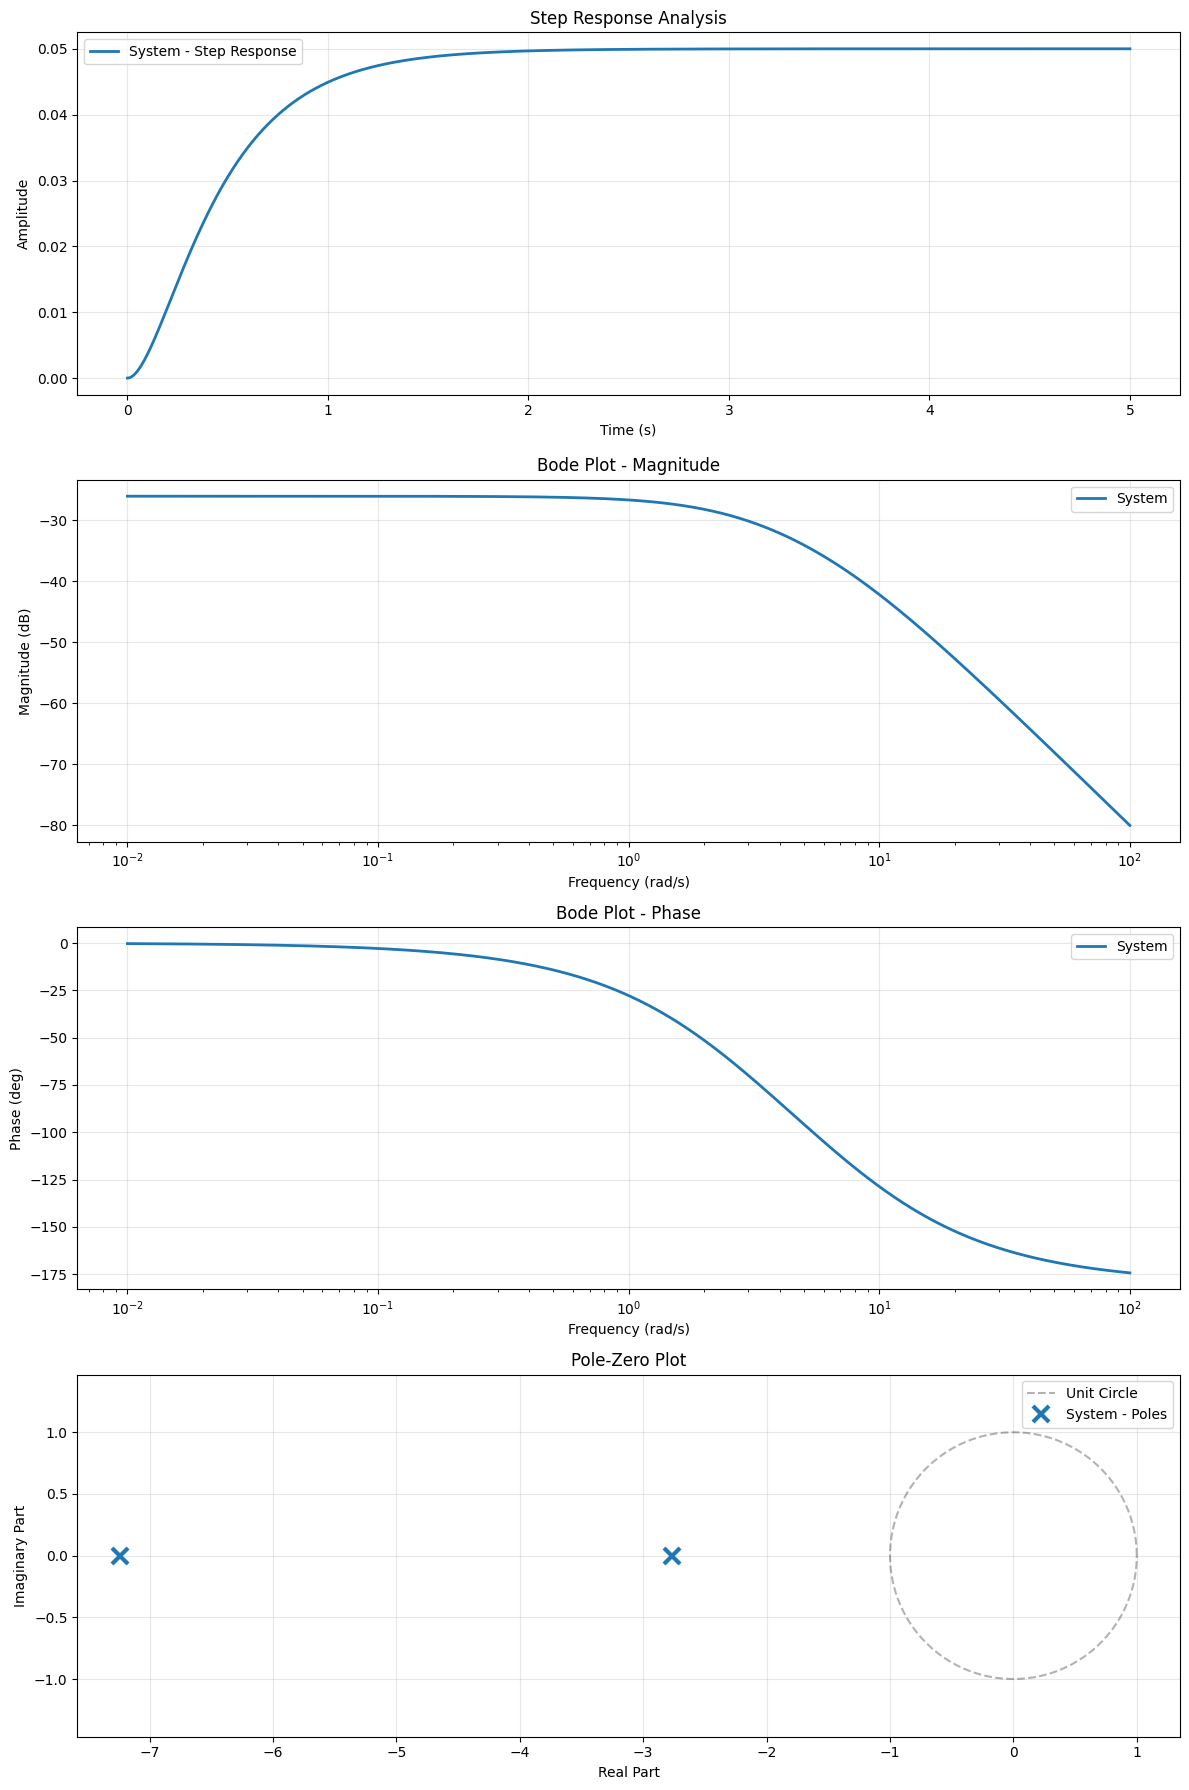

## Key Parameters

| Parameter | Unit | System |
|-----------|------|------|
| **DC Gain** | - | 0.0500 |
| **Rise Time** | s | 0.8809 |
| **Overshoot** | % | 0.00 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 |
| **Stability** | - | STABLE |


In [3]:
# Create open loop transfer function
open_loop_system = ctrl.TransferFunction([1], [1, 10, 20])

# Perform complete analysis function (detailed mode)
analyze_and_plot_transfer_function(open_loop_system)

![2](./script/2.jpeg)

# Controlador proporcional

## Estabilidade do Sistema com Ganho $K_p$

O sistema em malha aberta é:
$$
G(s) = \frac{1}{s^2 + 10s + 20}
$$

Com um controlador proporcional $C(s) = K_p$, a função de transferência em malha fechada é:
$$
T(s) = \frac{K_p G(s)}{1 + K_p G(s)}
$$

A equação característica é:
$$
1 + K_p G(s) = 0
$$

Ou seja:
$$
s^2 + 10s + (20 + K_p) = 0
$$

---

### Condições para estabilidade

Para um sistema de 2ª ordem:
$$
s^2 + a_1 s + a_0
$$

O sistema é estável se:
- $a_1 > 0$  
- $a_0 > 0$

Aqui $a_1 = 10 > 0$ sempre, e $a_0 = 20 + K_p$, então precisamos:
$$
20 + K_p > 0
$$

Ou seja:
$$
K_p > -20
$$


Então, como nos controladores o valor de $K_p$ comumente é usado como um valor positivo, não existe limite para $K_p$ para que o sistema seja estável.

## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 100

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300

<IPython.core.display.Math object>

### Closed Loop System: Kp = 1000

<IPython.core.display.Math object>

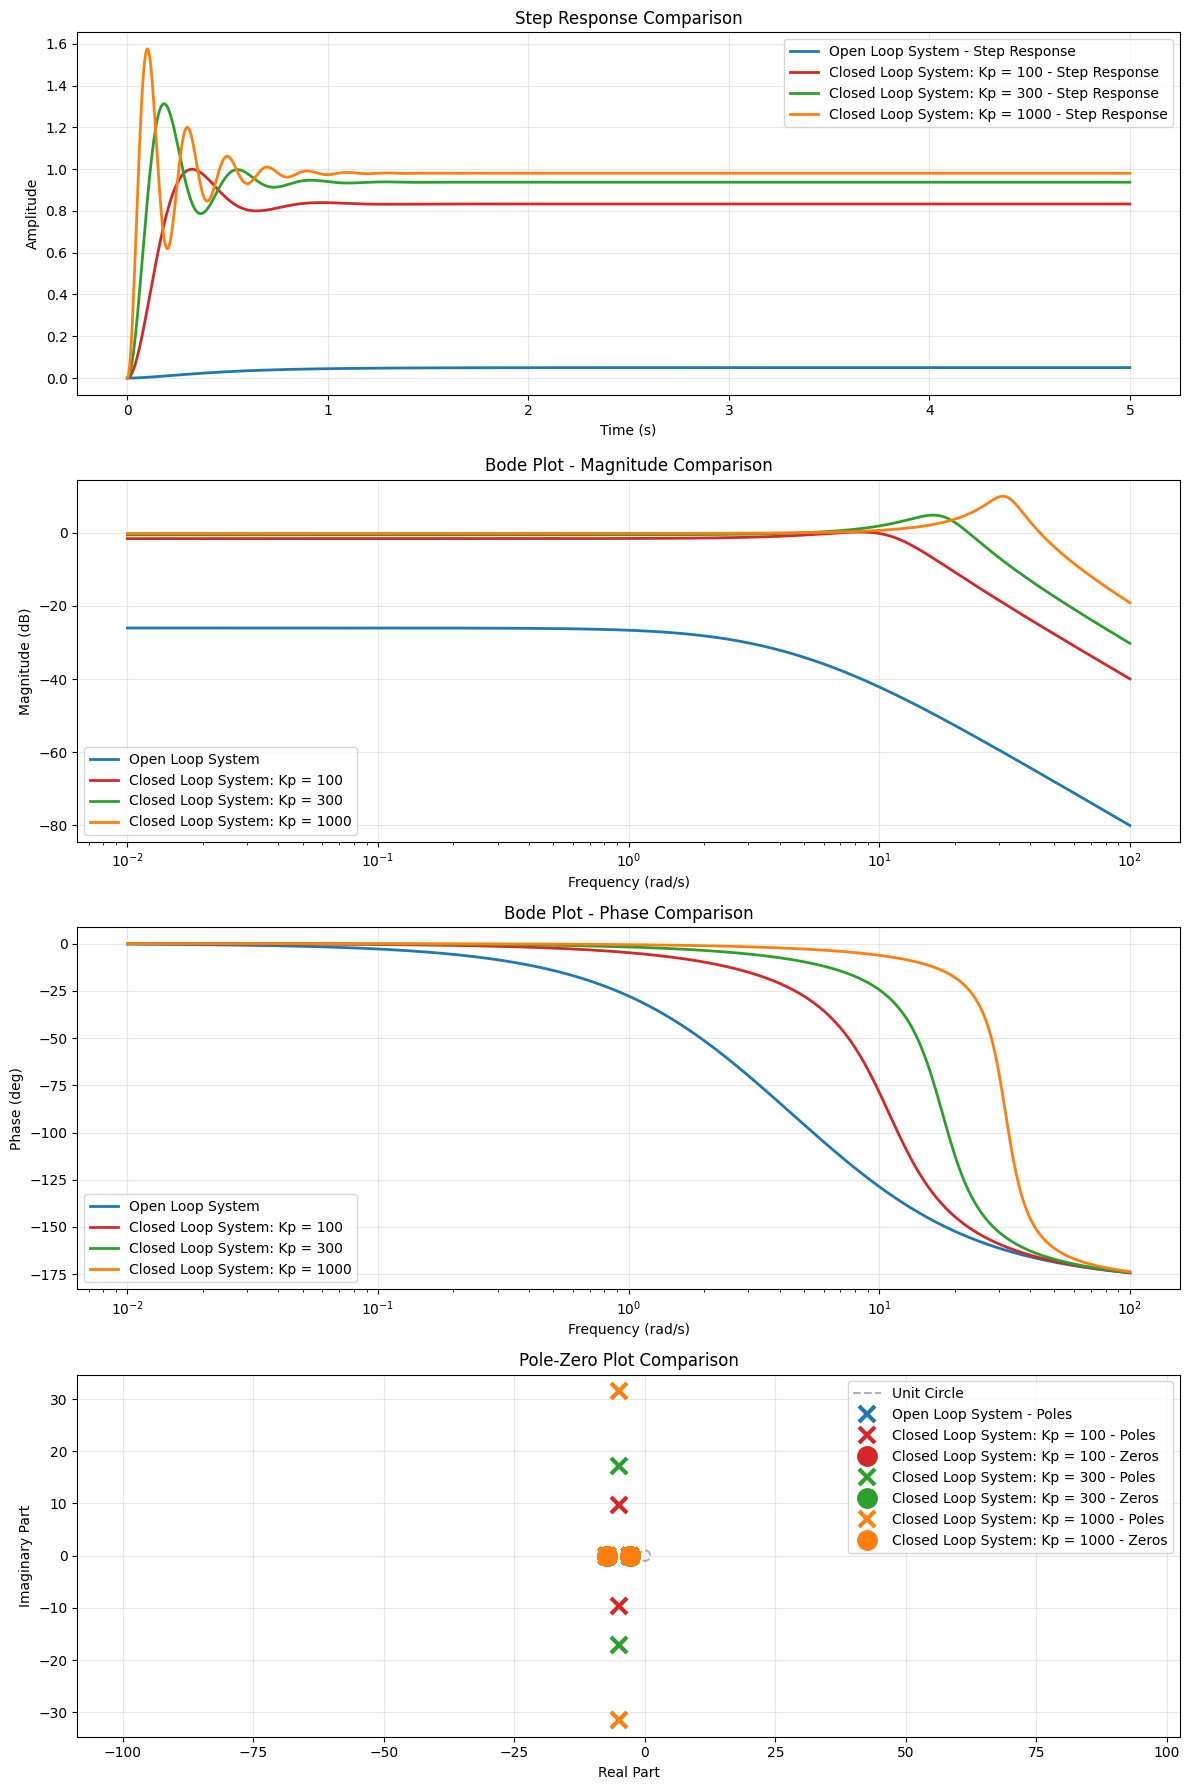

## Key Parameters

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 100 | Closed Loop System: Kp = 300 | Closed Loop System: Kp = 1000 |
|-----------|------|------|------|------|------|
| **DC Gain** | - | 0.0500 | 0.8333 | 0.9375 | 0.9804 |
| **Rise Time** | s | 0.8809 | 0.1451 | 0.0701 | 0.0400 |
| **Overshoot** | % | 0.00 | 19.95 | 40.04 | 60.77 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 | 14.560 | 26.268 | 49.169 |
| **Stability** | - | STABLE | STABLE | STABLE | STABLE |


In [4]:
# Closed loop response

controller_p_100  = create_pid(kp=100)
controller_p_300 = create_pid(kp=300)
controller_p_1000 = create_pid(kp=1000)

plant = open_loop_system

closed_loop_system_100 = controller_p_100 * plant / (1 + controller_p_100 * plant)
closed_loop_system_300 = controller_p_300 * plant / (1 + controller_p_300 * plant)
closed_loop_system_1000 = controller_p_1000 * plant / (1 + controller_p_1000 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 100": closed_loop_system_100,
		"Closed Loop System: Kp = 300": closed_loop_system_300,
		"Closed Loop System: Kp = 1000": closed_loop_system_1000
	},
)

# Controlador proporcional derivativo


## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300, Kd = 10

<IPython.core.display.Math object>

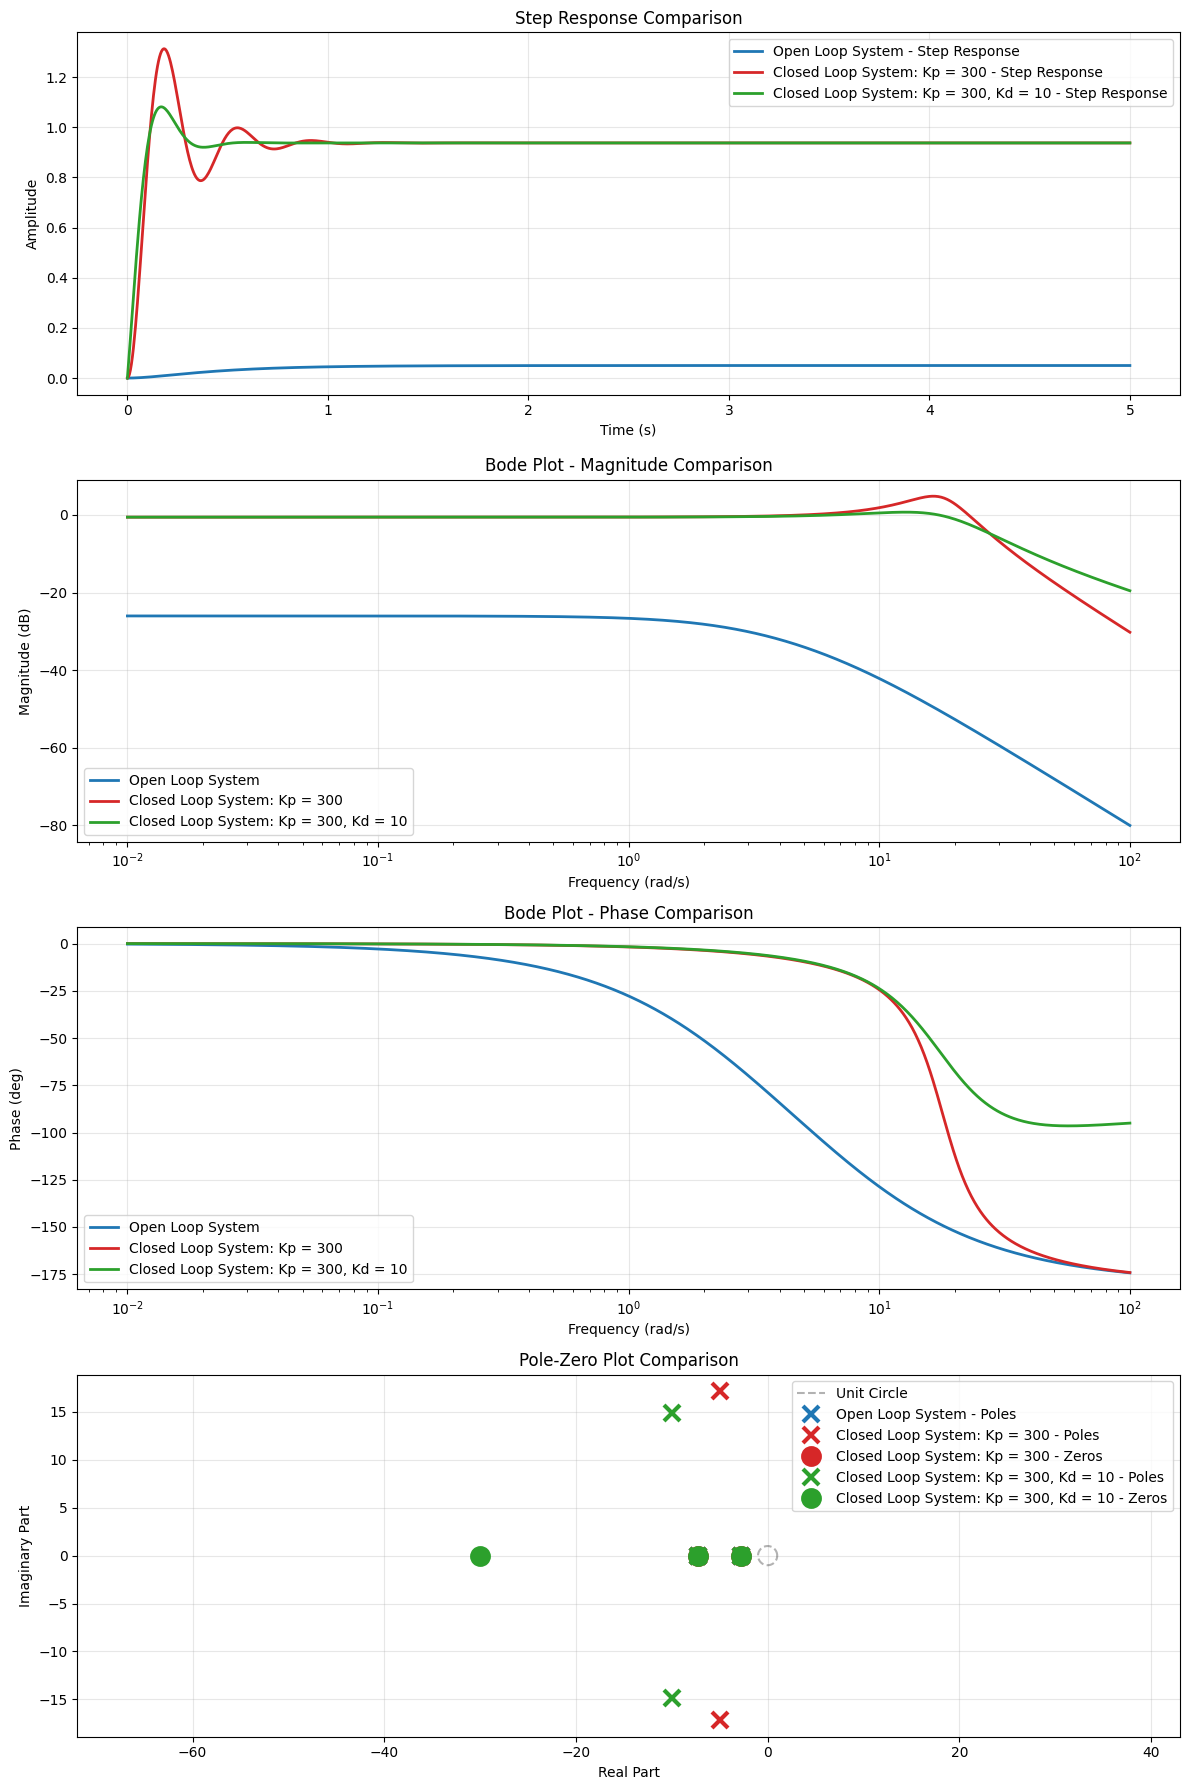

## Key Parameters

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 300 | Closed Loop System: Kp = 300, Kd = 10 |
|-----------|------|------|------|------|
| **DC Gain** | - | 0.0500 | 0.9375 | 0.9375 |
| **Rise Time** | s | 0.8809 | 0.0701 | 0.0801 |
| **Overshoot** | % | 0.00 | 40.04 | 15.34 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 | 26.268 | 25.084 |
| **Stability** | - | STABLE | STABLE | STABLE |


In [5]:
# Closed loop response

controller_p_300 = create_pid(kp=300)
controller_p_300_d_10 = create_pid(kp=300, kd=10)

plant = open_loop_system

closed_loop_system_300 = controller_p_300 * plant / (1 + controller_p_300 * plant)
closed_loop_system_300_d_10 = controller_p_300_d_10 * plant / (1 + controller_p_300_d_10 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 300": closed_loop_system_300,
		"Closed Loop System: Kp = 300, Kd = 10": closed_loop_system_300_d_10
	}
)

# Controlador proporcional integrador


## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300, Ki = 70

<IPython.core.display.Math object>

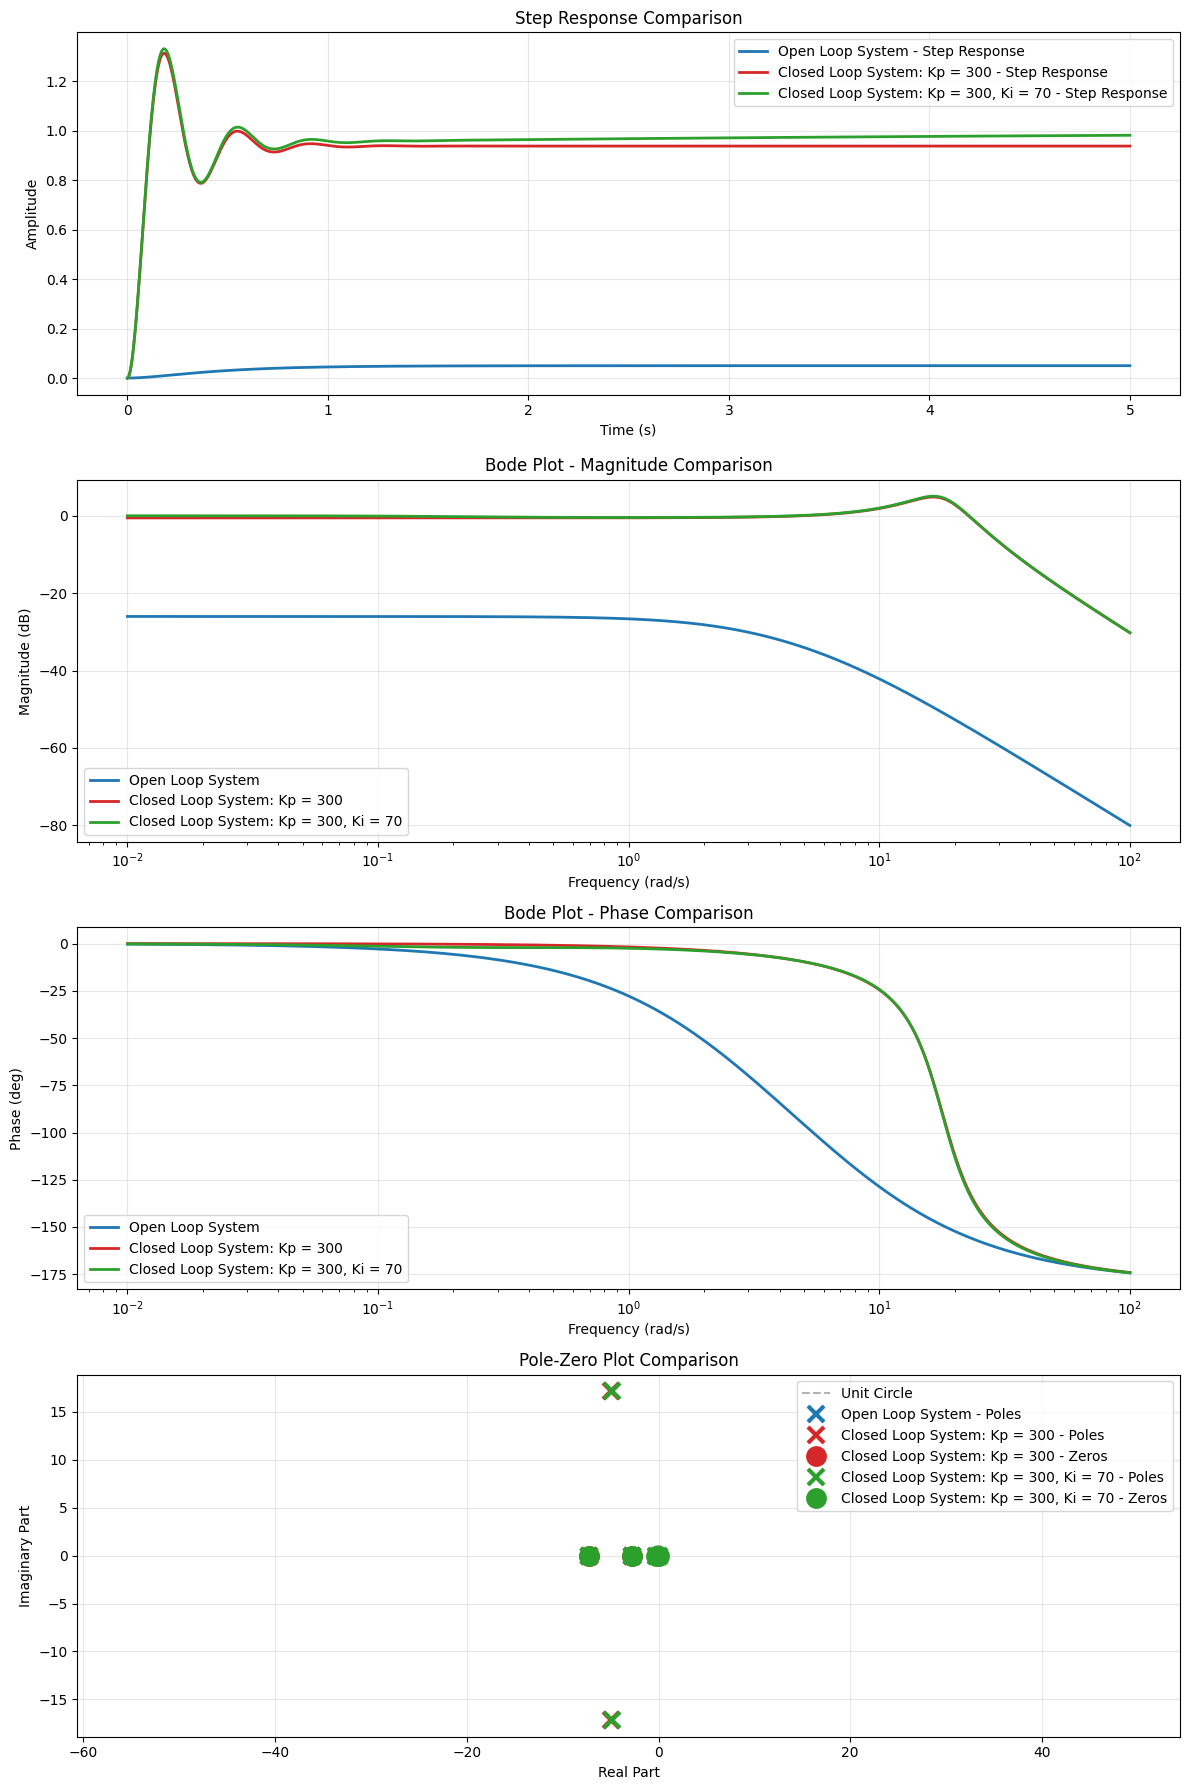

## Key Parameters

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 300 | Closed Loop System: Kp = 300, Ki = 70 |
|-----------|------|------|------|------|
| **DC Gain** | - | 0.0500 | 0.9375 | 0.9812 |
| **Rise Time** | s | 0.8809 | 0.0701 | 0.0751 |
| **Overshoot** | % | 0.00 | 40.04 | 35.61 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 | 26.268 | 26.026 |
| **Stability** | - | STABLE | STABLE | UNSTABLE |


In [6]:
# Closed loop response

controller_p_300 = create_pid(kp=300)
controller_p_300_i_70 = create_pid(kp=300, ki=70)

plant = open_loop_system

closed_loop_system_300 = controller_p_300 * plant / (1 + controller_p_300 * plant)
closed_loop_system_300_i_70 = controller_p_300_i_70 * plant / (1 + controller_p_300_i_70 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 300": closed_loop_system_300,
		"Closed Loop System: Kp = 300, Ki = 70": closed_loop_system_300_i_70
	}
)

# Controlador PID

## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300, Ki = 70, Kd = 10

<IPython.core.display.Math object>

### Closed Loop System: Kp = 350, Ki = 300, Kd = 50

<IPython.core.display.Math object>

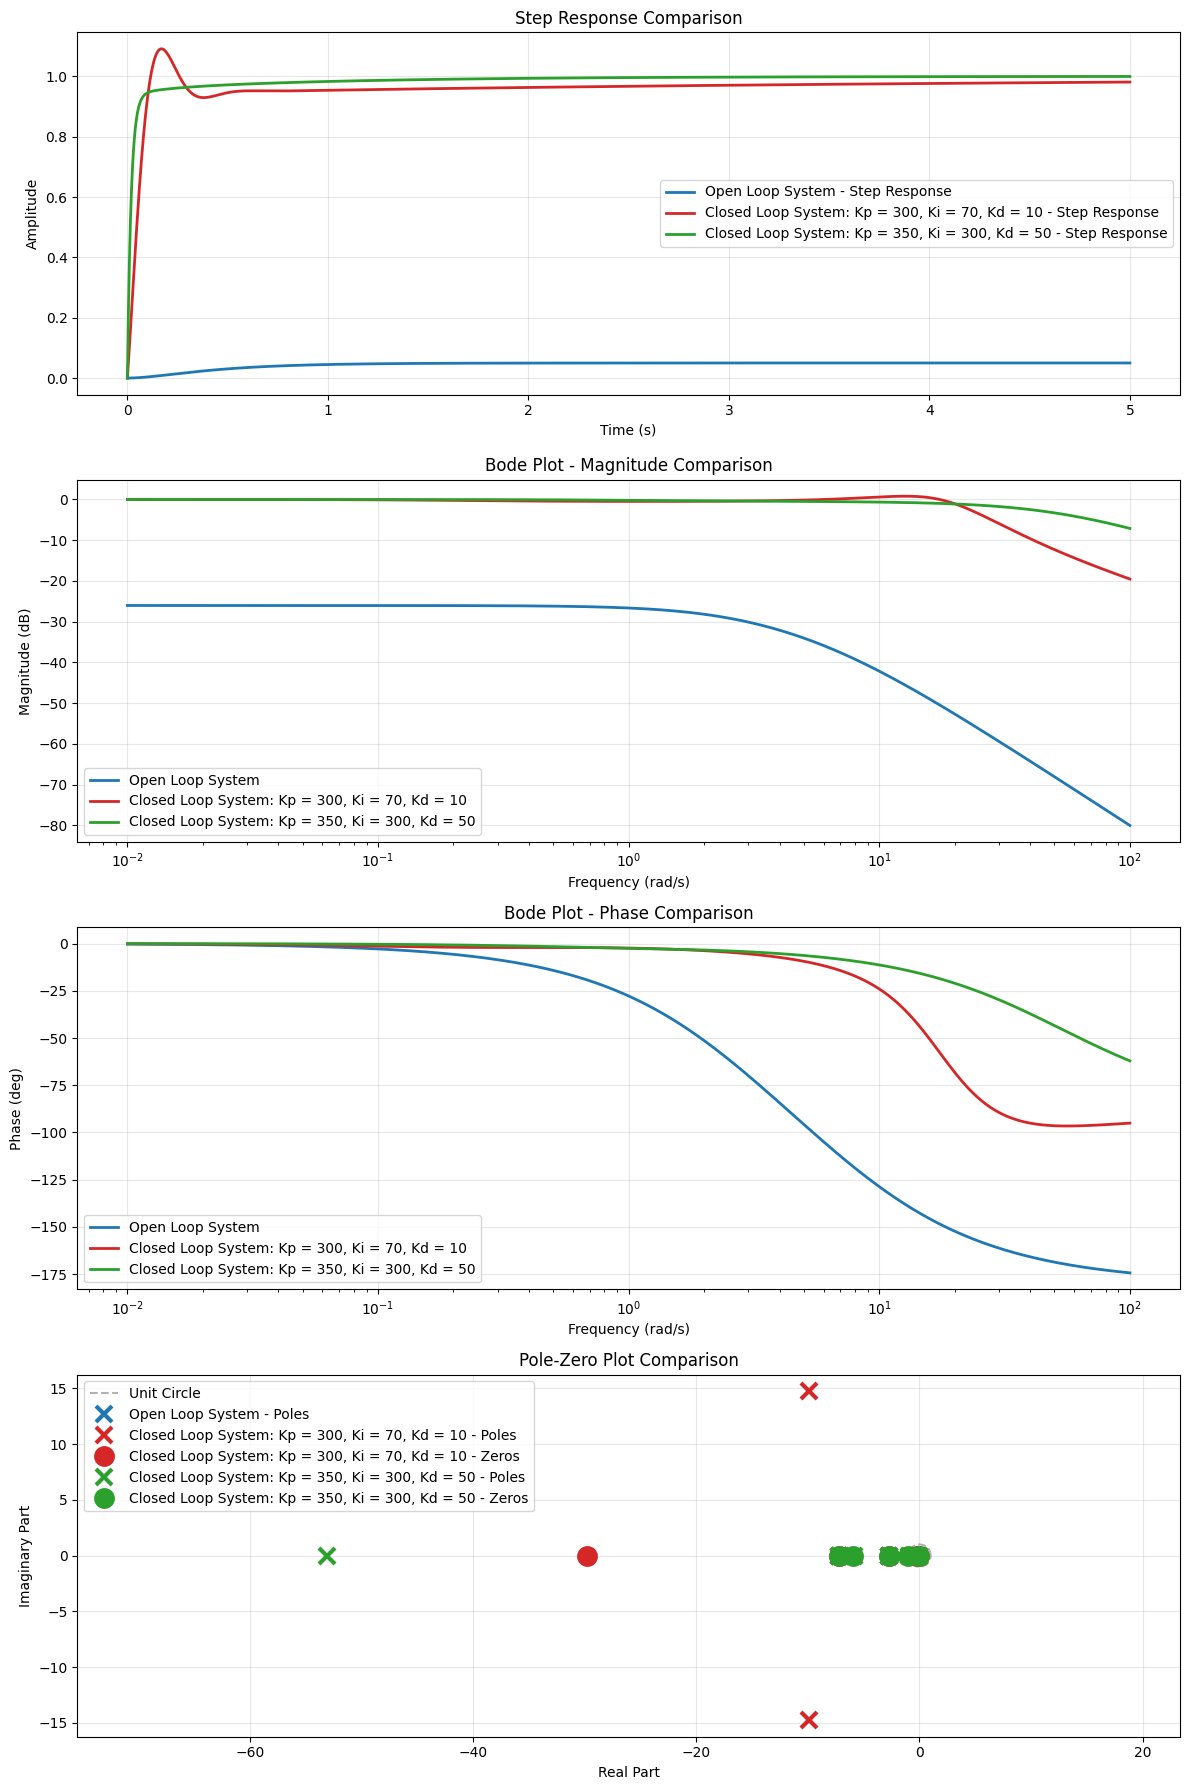

## Key Parameters

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 300, Ki = 70, Kd = 10 | Closed Loop System: Kp = 350, Ki = 300, Kd = 50 |
|-----------|------|------|------|------|
| **DC Gain** | - | 0.0500 | 0.9811 | 0.9996 |
| **Rise Time** | s | 0.8809 | 0.0851 | 0.0551 |
| **Overshoot** | % | 0.00 | 11.23 | 0.00 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 | 24.400 | 46.954 |
| **Stability** | - | STABLE | UNSTABLE | UNSTABLE |


In [7]:
# Closed loop response

controller_p_300_i_70_d_10 = create_pid(kp=300, ki=70, kd=10)
controller_p_350_i_300_d_50 = create_pid(kp=350, ki=300, kd=50)

plant = open_loop_system

closed_loop_system_300_i_70_d_10 = controller_p_300_i_70_d_10 * plant / (1 + controller_p_300_i_70_d_10 * plant)
closed_loop_system_350_i_300_d_50 = controller_p_350_i_300_d_50 * plant / (1 + controller_p_350_i_300_d_50 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 300, Ki = 70, Kd = 10": closed_loop_system_300_i_70_d_10,
		"Closed Loop System: Kp = 350, Ki = 300, Kd = 50": closed_loop_system_350_i_300_d_50
	}
)

![](./script/3.jpeg)

### Ajustando o proprcional (Sempre vai ser estavel para este caso, mas vai ser limitado a 900, pois na vida real pode causar instabilidade), foi escolhido 900

### Ajustando o Derivativo ate zerar o overshoot

## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

### Closed Loop System: Kp = 350, Ki = 300, Kd = 50

<IPython.core.display.Math object>

### Closed Loop System: Kp = 350 (intuitive)

<IPython.core.display.Math object>

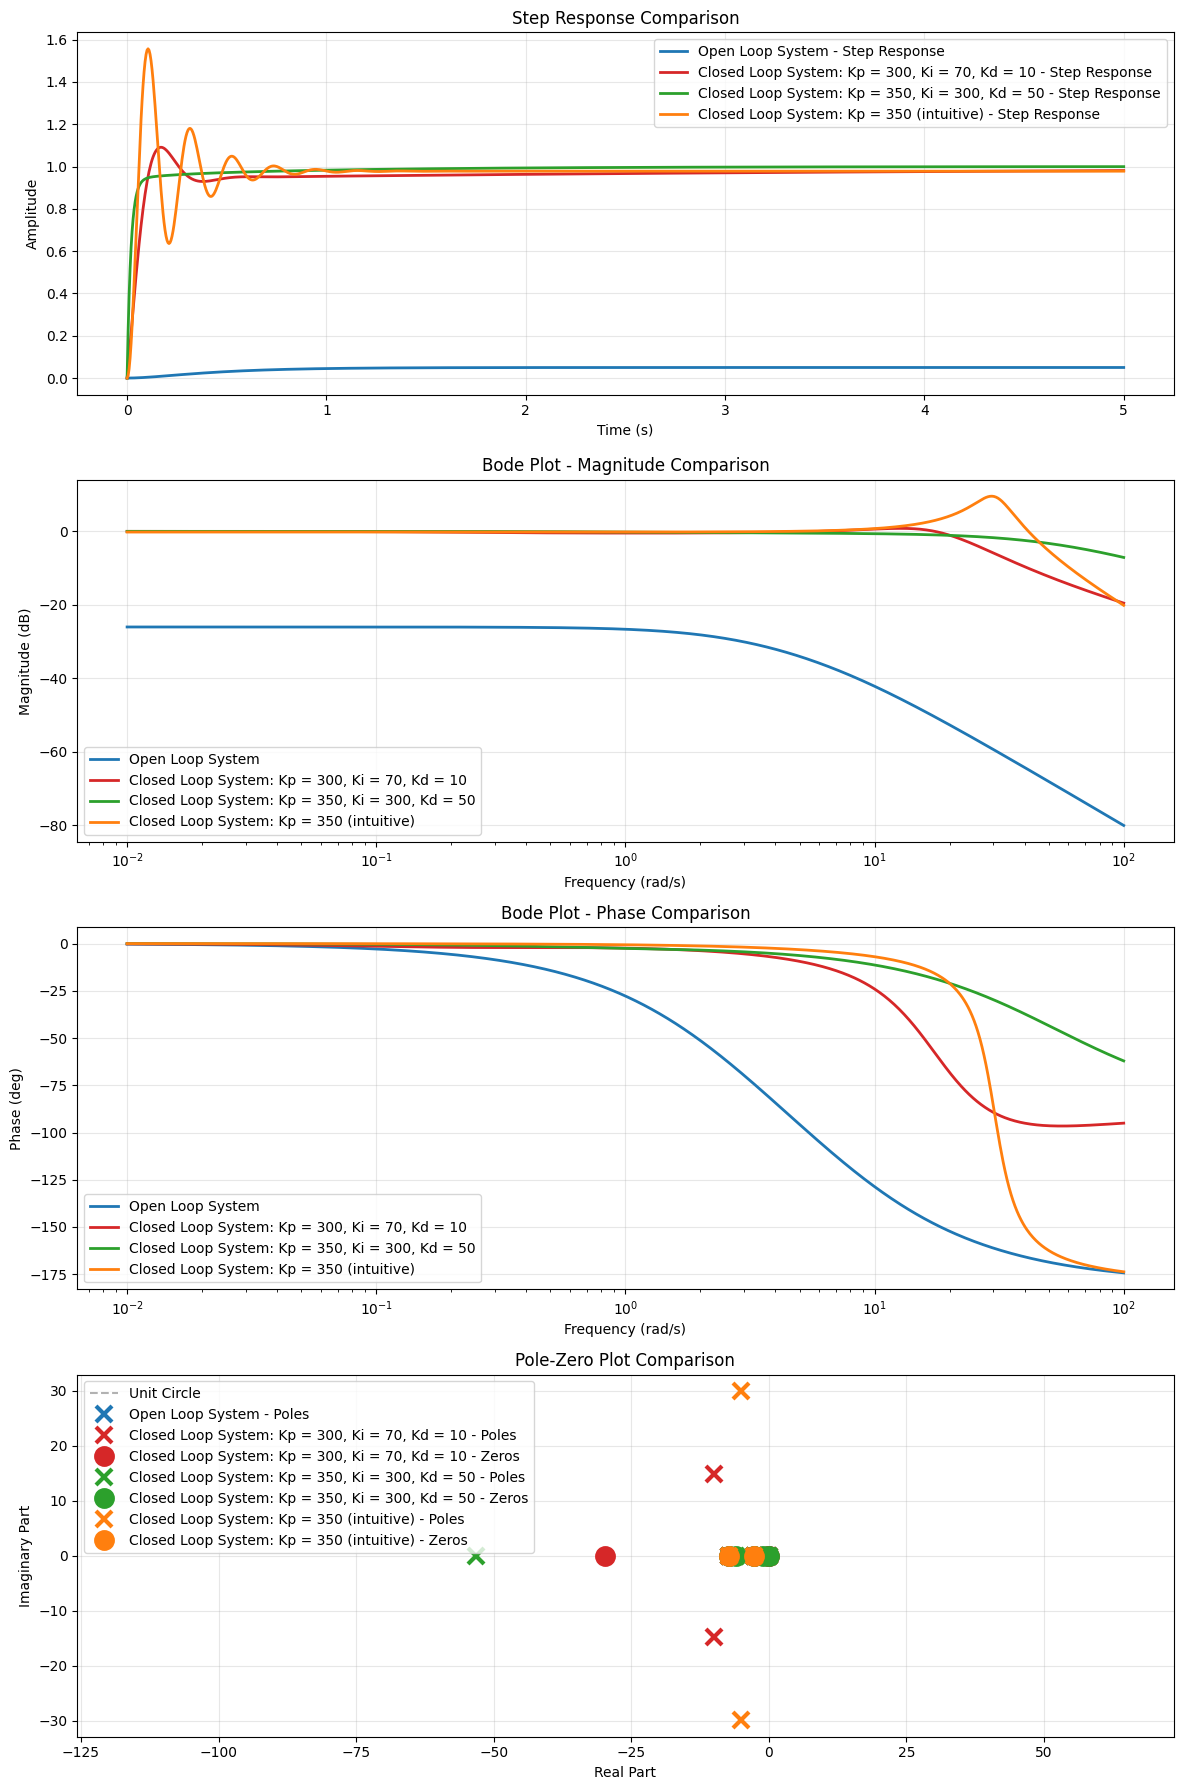

## Key Parameters

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 300, Ki = 70, Kd = 10 | Closed Loop System: Kp = 350, Ki = 300, Kd = 50 | Closed Loop System: Kp = 350 (intuitive) |
|-----------|------|------|------|------|------|
| **DC Gain** | - | 0.0500 | 0.9811 | 0.9996 | 0.9783 |
| **Rise Time** | s | 0.8809 | 0.0851 | 0.0551 | 0.0350 |
| **Overshoot** | % | 0.00 | 11.23 | 0.00 | 59.15 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 | 24.400 | 46.954 | 46.523 |
| **Stability** | - | STABLE | UNSTABLE | UNSTABLE | STABLE |


In [ ]:
# Closed loop response

controller_p_300_i_70_d_10 = create_pid(kp=300, ki=70, kd=10)
controller_p_350_i_300_d_50 = create_pid(kp=350, ki=300, kd=50)


controller_p_intuitive = create_pid(kp=900, ki=0, kd=0)
display(Markdown("**Ajustando o proprcional (Sempre vai ser estavel para este caso, mas vai ser limitado a 900, pois na vida real pode causar instabilidade), foi escolhido 900**"))

control_pd_intuitive = create_pid(kp=900, ki=0, kd=130)
display(Markdown("**Ajustando o Derivativo ate zerar o overshoot**"))

plant = open_loop_system

closed_loop_system_300_i_70_d_10 = controller_p_300_i_70_d_10 * plant / (1 + controller_p_300_i_70_d_10 * plant)
closed_loop_system_350_i_300_d_50 = controller_p_350_i_300_d_50 * plant / (1 + controller_p_350_i_300_d_50 * plant)
closed_loop_system_intuitive = controller_p_intuitive * plant / (1 + controller_p_intuitive * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 300, Ki = 70, Kd = 10": closed_loop_system_300_i_70_d_10,
		"Closed Loop System: Kp = 350, Ki = 300, Kd = 50": closed_loop_system_350_i_300_d_50,
		"Closed Loop System: Kp = 350 (intuitive)": closed_loop_system_intuitive
	}
)

# Otimizador

In [9]:
import numpy as np
from scipy import optimize

def _phase_margin(L: ctrl.TransferFunction) -> float:
	"""Margem de fase (graus) de L(s)=C(s)·G(s)."""
	_, pm, *_ = ctrl.stability_margins(L)
	return pm

def tune_p(plant: ctrl.TransferFunction, target_pm: float = 60.0) -> float:
	"""Ajusta apenas Kp (controlador P)."""
	cost = lambda K: (_phase_margin(K * plant) - target_pm) ** 2
	res  = optimize.minimize_scalar(cost, bounds=(1e-2, 1e3), method="bounded")
	return res.x

def tune_pi(plant: ctrl.TransferFunction, target_pm: float = 60.0) -> tuple[float, float]:
	"""Ajusta (Kp, Ki) para um PI."""
	def cost(x):
		Kp, Ki = x
		C = ctrl.TransferFunction([Kp, Ki], [1, 0])
		return (_phase_margin(C * plant) - target_pm) ** 2
	res = optimize.minimize(cost, x0=[1.0, 1.0],
							bounds=[(1e-2, 1e3), (1e-2, 1e3)])
	return tuple(res.x)

def tune_pid(plant: ctrl.TransferFunction, target_pm: float = 60.0) -> tuple[float, float, float]:
	"""Ajusta (Kd, Kp, Ki) para um PID."""
	def cost(x):
		Kd, Kp, Ki = x
		C = ctrl.TransferFunction([Kd, Kp, Ki], [1, 0])
		return (_phase_margin(C * plant) - target_pm) ** 2
	res = optimize.minimize(cost, x0=[0.1, 1.0, 1.0],
							bounds=[(0.0, 100.0), (1e-2, 1e3), (1e-2, 1e3)])
	return tuple(res.x)

Kp: 1.3779257234354707, Ki: 1.3122683298370994, Kd: 29.058867472006906


## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Optimized

<IPython.core.display.Math object>

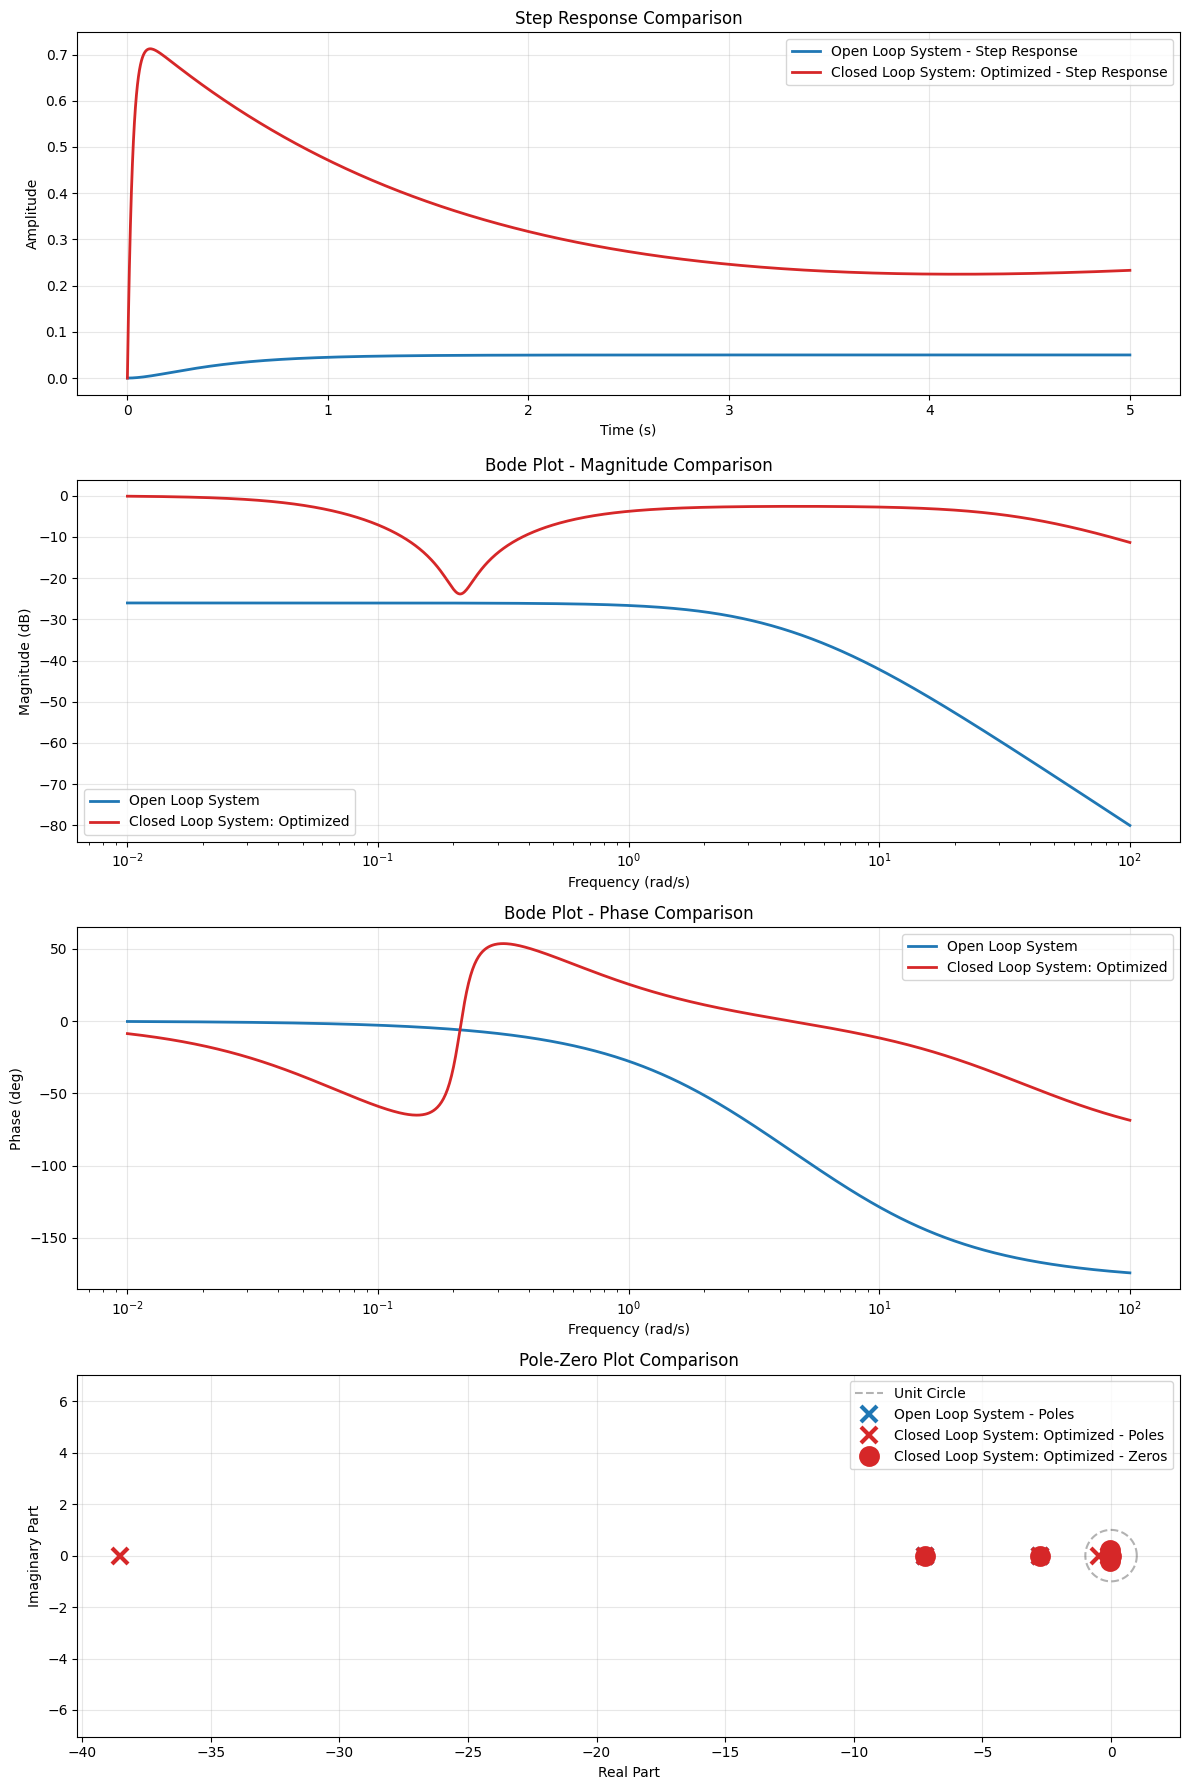

## Key Parameters

| Parameter | Unit | Open Loop System | Closed Loop System: Optimized |
|-----------|------|------|------|
| **DC Gain** | - | 0.0500 | 0.2331 |
| **Rise Time** | s | 0.8809 | 0.0050 |
| **Overshoot** | % | 0.00 | 205.66 |
| **Bandwidth (-3 dB)** | rad/s | 2.457 | 0.165 |
| **Stability** | - | STABLE | UNSTABLE |


In [10]:
# Closed loop response

kp, ki, kd = tune_pid(open_loop_system, target_pm=60)

print(f"Kp: {kp}, Ki: {ki}, Kd: {kd}")
controller_optimized = create_pid(kp=kp, ki=ki, kd=kd)


plant = open_loop_system

closed_loop_system_optimized = controller_optimized * plant / (1 + controller_optimized * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Optimized": closed_loop_system_optimized
	}
)

# Ajuste do PID usando PID_Designer